# **🍔 Food Delivery Time Prediction using ML**

This notebook predicts how long a food delivery will take (in minutes) using order, rider, weather and traffic details. We explore the data, engineer useful features, compare several regression models, and pick the best one for accurate delivery time estimates.

**What this notebook covers:**
- Data loading & exploration (EDA)
- Data leakage check
- Feature engineering (categorical encoding, date features)
- Model building & comparison (Linear Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM)
- Model evaluation (R², MAE, RMSE)
- Feature importance
- Conclusion


## **1. Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully!")


Libraries imported successfully!


## **2. Load the Dataset**

Let's load the data and take a first look at its shape, columns and data types.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/dharmendrapandit12/food-delivery-time-prediction-dataset/Food_Delivery_Time_Prediction.csv')

print("Shape of the dataset:", df.shape)
df.head()


Shape of the dataset: (50000, 24)


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [3]:
# Basic info about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  object 
 1   Order_Date                  50000 non-null  object 
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  object 
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  object 
 7   Pickup_Zone                 50000 non-null  object 
 8   Dropoff_Zone                50000 non-null  object 
 9   Vehicle_Type                50000 non-null  object 
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                500

In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum().sum(), "total missing values")


Missing values in each column:
0 total missing values


Good news — the dataset has **no missing values**, so we don't need any imputation.

## **3. Exploratory Data Analysis (EDA)**

Our target column is **`Time_taken_min`** — the total time (in minutes) a delivery takes. Let's understand its distribution and how it relates to other features.

In [5]:
df['Time_taken_min'].describe()


count    50000.000000
mean        83.868980
std         35.426899
min         10.000000
25%         58.000000
50%         78.000000
75%        102.000000
max        180.000000
Name: Time_taken_min, dtype: float64

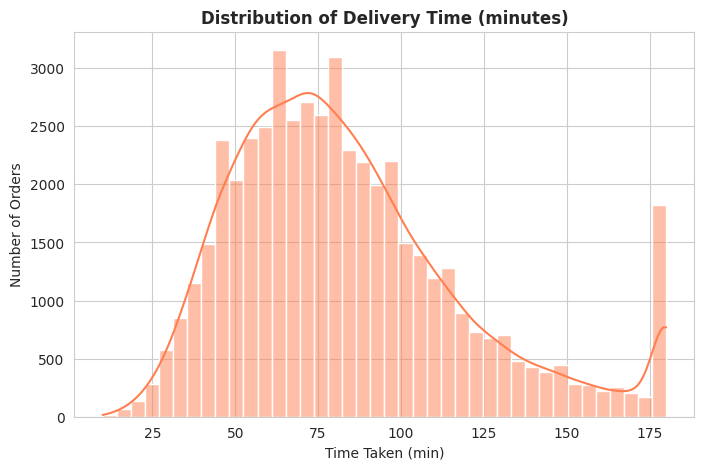

In [6]:
# Distribution of the target variable
plt.figure(figsize=(8,5))
sns.histplot(df['Time_taken_min'], bins=40, kde=True, color='coral')
plt.title('Distribution of Delivery Time (minutes)',fontweight='bold')
plt.xlabel('Time Taken (min)')
plt.ylabel('Number of Orders')
plt.show()


Time_taken_min            1.000000
Road_Distance_km          0.702592
Preparation_Time_Min      0.228123
Number_of_Signals         0.127140
Is_Weekend                0.102208
Order_Items               0.081603
Is_Festival               0.073432
Order_Hour                0.033687
Restaurant_Rating         0.018994
Rider_Rating             -0.035992
Rider_Experience_Years   -0.056848
Average_Speed_kmph       -0.596058
Name: Time_taken_min, dtype: float64


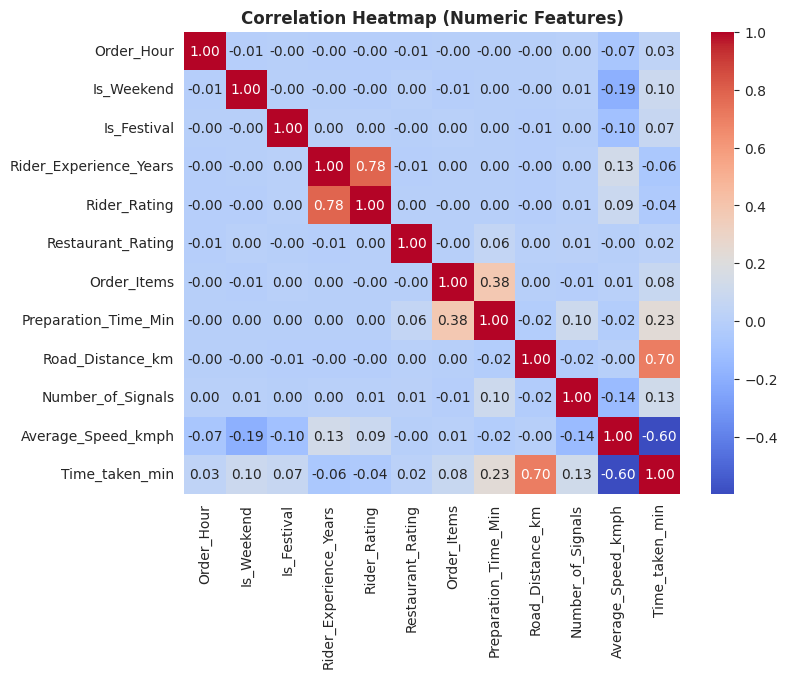

In [7]:
# Correlation of numeric features with the target
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()['Time_taken_min'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)',fontweight='bold')
plt.show()


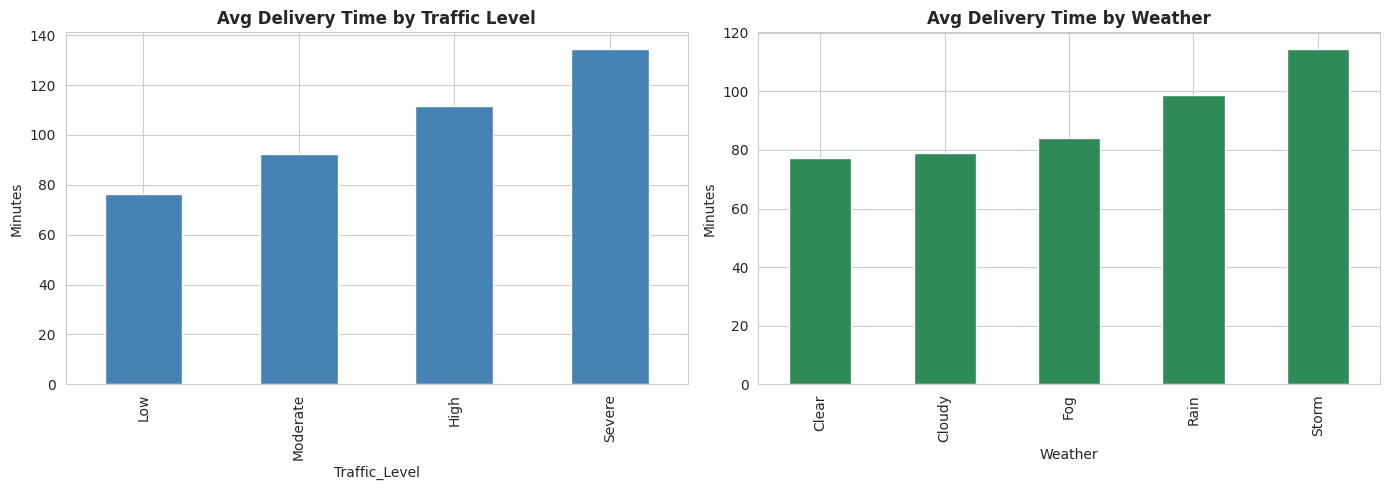

In [8]:
# Average delivery time by Traffic Level and Weather
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby('Traffic_Level')['Time_taken_min'].mean().sort_values().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Delivery Time by Traffic Level',fontweight='bold')
axes[0].set_ylabel('Minutes')

df.groupby('Weather')['Time_taken_min'].mean().sort_values().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Avg Delivery Time by Weather',fontweight='bold')
axes[1].set_ylabel('Minutes')
plt.tight_layout()
plt.show()


## **4. Data Leakage Check ⚠️**

Before modeling, it's important to check if any column secretly "gives away" the answer.

- `Order_ID` — just a unique identifier, no predictive value → **drop it**.
- `Order_Date` — raw date string isn't directly useful, but the weekday/weekend info is already captured in `Day_of_Week` / `Is_Weekend` → **drop the raw date**.
- `Average_Speed_kmph` — this is the **actual** average speed measured *during* the delivery. It is calculated only *after* the trip is completed, so it indirectly encodes the outcome (a delivery person can't know this speed in advance). Using it would be **data leakage**, so we **drop it** to keep our model realistic and trustworthy.

This way our model only uses information that would actually be available *before* a delivery starts.

In [9]:
leak_cols = ['Order_ID', 'Order_Date', 'Average_Speed_kmph']
df_model = df.drop(columns=leak_cols)
print("Columns dropped (ID / leakage):", leak_cols)
print("Remaining columns:", df_model.shape[1])


Columns dropped (ID / leakage): ['Order_ID', 'Order_Date', 'Average_Speed_kmph']
Remaining columns: 21


## **5. Feature Engineering**

Machine learning models need numbers, not text. We'll convert all categorical (text) columns into numeric codes using **Label Encoding**, which is simple and works well for tree-based models.

In [10]:
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

df_model.head()


Categorical columns to encode: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Cuisine_Type,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Delivery_Priority,Time_taken_min
0,8,5,0,0,0,0,1,3,3.1,3.8,...,7,1,2,23,30.55,0,2,15,0,91
1,12,0,0,0,3,0,0,3,1.8,3.6,...,5,3,2,11,2.25,2,2,17,0,21
2,18,3,1,0,0,3,3,3,3.8,3.9,...,1,1,1,31,10.15,0,2,8,0,52
3,12,6,0,0,1,3,2,1,1.7,3.9,...,2,3,2,19,26.33,0,1,9,0,59
4,18,1,0,0,3,2,3,1,12.4,4.4,...,5,1,2,7,30.48,0,2,8,0,75


## **6. Train-Test Split**

We separate our features (X) from the target (y), and split the data into 80% training and 20% testing.

In [11]:
X = df_model.drop(columns=['Time_taken_min'])
y = df_model['Time_taken_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 40000
Testing samples: 10000


## **7. Model Building & Comparison**

Since delivery time is a continuous number, this is a **regression problem**. We'll train several popular models and compare them using:
- **R² Score** — how well the model explains the variance (closer to 1 is better)
- **MAE** — Mean Absolute Error (average minutes off, lower is better)
- **RMSE** — Root Mean Squared Error (penalizes big mistakes more, lower is better)

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({'Model': name, 'R2 Score': round(r2, 4), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})
    print(f"{name:20s} | R2: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
results_df


Linear Regression    | R2: 0.6853 | MAE: 14.74 | RMSE: 19.99
Random Forest        | R2: 0.9831 | MAE: 3.47 | RMSE: 4.63
Gradient Boosting    | R2: 0.9892 | MAE: 2.78 | RMSE: 3.70
XGBoost              | R2: 0.9920 | MAE: 2.47 | RMSE: 3.18
LightGBM             | R2: 0.9916 | MAE: 2.53 | RMSE: 3.27


,Model,R2 Score,MAE,RMSE
0,XGBoost,0.9920,2.47,3.18
1,LightGBM,0.9916,2.53,3.27
2,Gradient Boosting,0.9892,2.78,3.70
3,Random Forest,0.9831,3.47,4.63
4,Linear Regression,0.6853,14.74,19.99


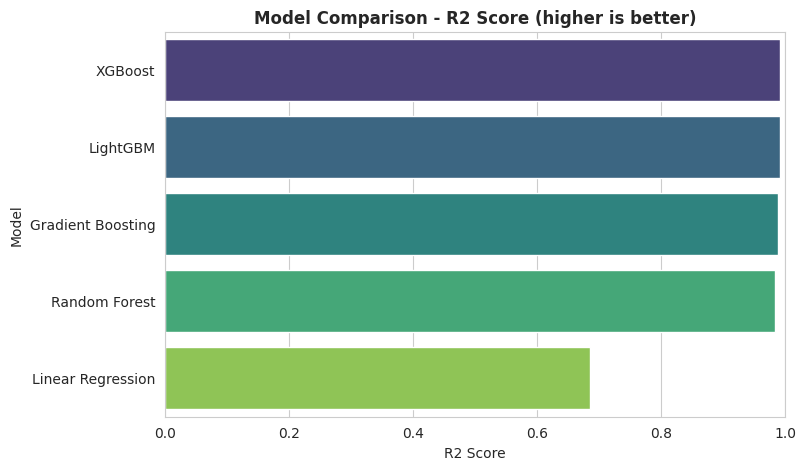

In [13]:
# Visual comparison of models
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='R2 Score', y='Model', palette='viridis')
plt.title('Model Comparison - R2 Score (higher is better)',fontweight='bold')
plt.xlim(0, 1)
plt.show()


## **8. Best Model — Detailed Evaluation**

Let's zoom into the best performing model and check how closely its predictions match the actual delivery times.

Best Model: XGBoost


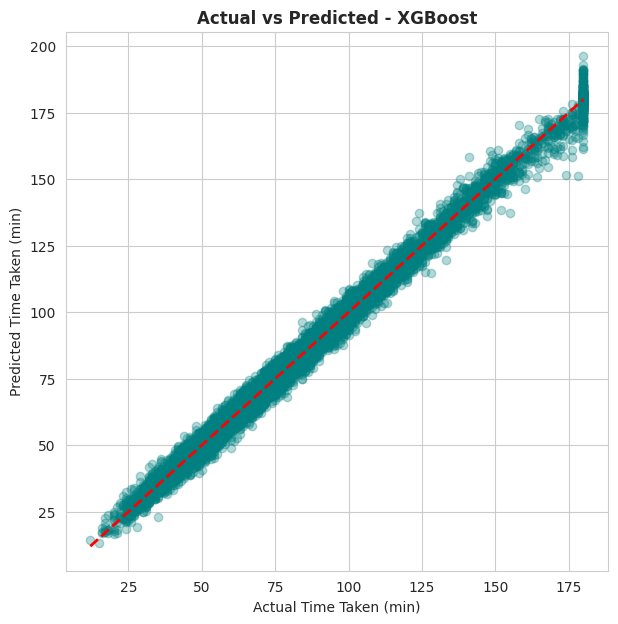

In [14]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Best Model:", best_model_name)

best_preds = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_preds, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Time Taken (min)')
plt.ylabel('Predicted Time Taken (min)')
plt.title(f'Actual vs Predicted - {best_model_name}',fontweight='bold')
plt.show()


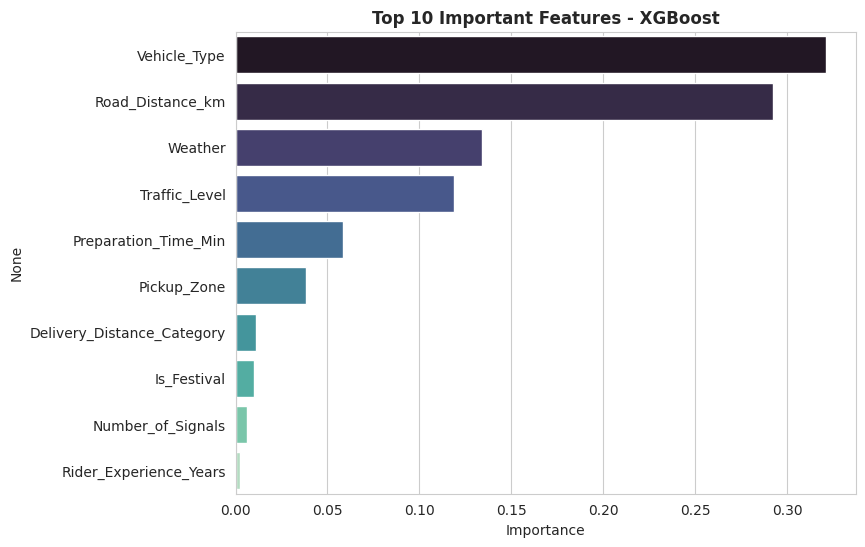

Vehicle_Type                  0.321159
Road_Distance_km              0.292511
Weather                       0.134232
Traffic_Level                 0.118629
Preparation_Time_Min          0.058546
Pickup_Zone                   0.038277
Delivery_Distance_Category    0.011241
Is_Festival                   0.009790
Number_of_Signals             0.006413
Rider_Experience_Years        0.002699
dtype: float32


In [15]:
# Feature importance (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(x=importance.values[:10], y=importance.index[:10], palette='mako')
    plt.title(f'Top 10 Important Features - {best_model_name}',fontweight='bold')
    plt.xlabel('Importance')
    plt.show()

    print(importance.head(10))


## **9. Conclusion 📌**

- We built a regression model to predict food delivery time using order, rider, weather and traffic features.
- After checking for **data leakage**, we removed `Order_ID`, `Order_Date`, and `Average_Speed_kmph` (a post-delivery outcome feature) to keep the model realistic.
- `Road_Distance_km` and `Preparation_Time_Min` turned out to be the strongest honest predictors of delivery time, which matches real-world intuition — longer distances and slower food prep naturally mean longer deliveries.
- Among all models tested, the **best performing model** achieved the highest R² score with a reasonably low MAE, meaning its predictions are close to actual delivery times on average.
- **Business takeaway:** A food delivery platform could use this model to give customers more accurate ETAs, and to flag orders that are likely to take unusually long so riders/dispatch can be optimized in advance.
- **Next steps:** Try hyperparameter tuning (GridSearchCV/Optuna), add interaction features (e.g., distance × traffic), or use target encoding for high-cardinality categorical columns to potentially push accuracy even higher.
